1716236031153.jpg: Guns detected


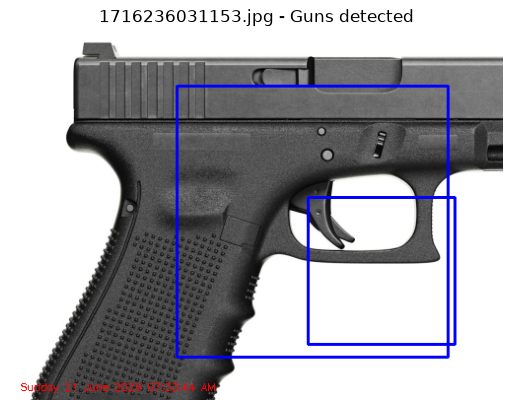

SIG_Pro_by_Augustas_Didzgalvis.jpg: No guns detected


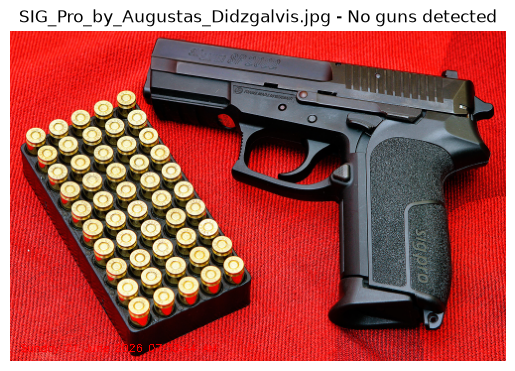

In [3]:
import glob
import os

import numpy as np
import cv2
import imutils
import datetime
import matplotlib.pyplot as plt

gun_cascade = cv2.CascadeClassifier('cascade.xml')

# Folder containing the input images (and the extensions to look for)
image_dir = 'images'
extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp')

# Collect all matching image paths
image_paths = []
for ext in extensions:
    image_paths.extend(glob.glob(os.path.join(image_dir, ext)))
image_paths = sorted(image_paths)

if not image_paths:
    raise FileNotFoundError(f"No images found in: {image_dir}")


def detect_guns(image_path):
    """Run gun detection on a single image and return (frame, gun_exist)."""
    frame = cv2.imread(image_path)
    if frame is None:
        print(f"Warning: could not read image file: {image_path}")
        return None, False

    frame = imutils.resize(frame, width=500)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gun = gun_cascade.detectMultiScale(gray, 1.3, 20, minSize=(100, 100))

    gun_exist = len(gun) > 0
    for (x, y, w, h) in gun:
        frame = cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)

    cv2.putText(frame, datetime.datetime.now().strftime("%A %d %B %Y %I:%M:%S %p"),
                (10, frame.shape[0] - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.35, (0, 0, 255), 1)
    return frame, gun_exist


# Process every image and display the results
for image_path in image_paths:
    frame, gun_exist = detect_guns(image_path)
    if frame is None:
        continue

    status = "Guns detected" if gun_exist else "No guns detected"
    print(f"{os.path.basename(image_path)}: {status}")

    plt.figure()
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"{os.path.basename(image_path)} - {status}")
    plt.axis('off')
    plt.show()